In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from dython.nominal import associations
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Data Analysis

## Checking correlation of features

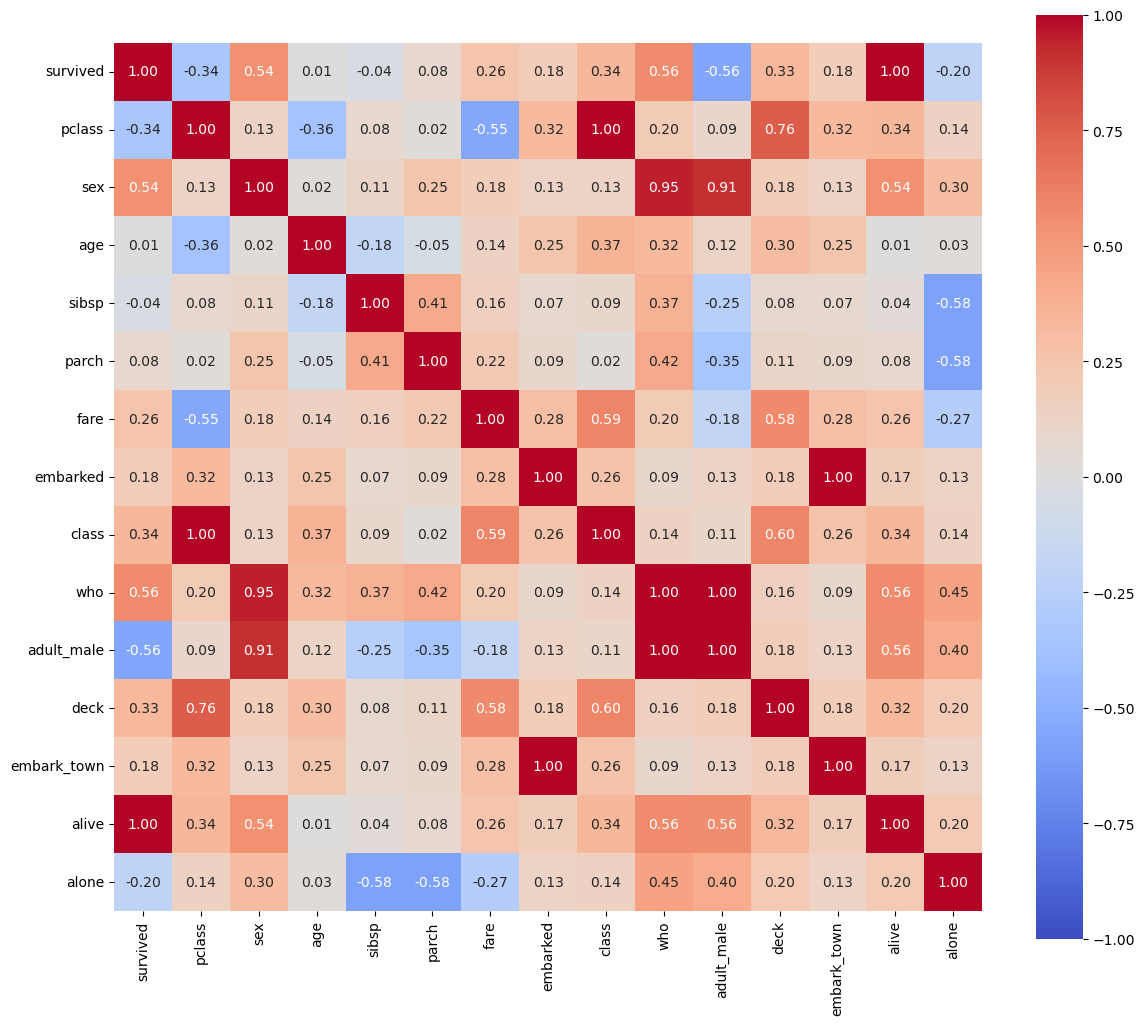

In [4]:
# Convert categorical columns to strings and replace NaNs
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    df[col] = df[col].astype(str).fillna("Missing")

result = associations(
    df,
    nominal_columns=cat_cols.tolist(),
    figsize=(14, 12),
    cmap="coolwarm",
    annot=True
)


In [5]:
df = df.drop(columns=['class', 'embarked', 'sex', 'alive', 'adult_male'])

In [6]:
df['deck']

0      nan
1        C
2      nan
3        C
4      nan
      ... 
886    nan
887      B
888    nan
889      C
890    nan
Name: deck, Length: 891, dtype: object

## Missing Values

In [7]:
# common placeholders for missing values
placeholders = ["nan", "NaN", "null", "NULL", "None", "", "?"]

df.replace(placeholders, np.nan, inplace=True)

In [8]:
missing_df = df.isna().sum().reset_index()
missing_df.columns = ['Column', 'Missing Count']
missing_df['Missing Percentage'] = (
    missing_df['Missing Count'] / len(df) * 100
)

fig = px.bar(
    missing_df,
    x = 'Column',
    y = 'Missing Count',
    custom_data = 'Missing Percentage',
    text = 'Missing Count',
    title = 'Missing Count in Each Feature'
)
fig.update_traces(
    hovertemplate = 
    "<b> %{x} <b> <br>" + 
    "Missing Count: %{y}<br>" +
    "Missing Percentage: %{customdata[0]:.2f}%"
)
fig.show()

In [9]:
df["age"] = df["age"].fillna(df["age"].median())

In [10]:
df['has_cabin'] = df['deck'].notna().astype(int)
df.drop(columns=['deck'], axis=1, inplace=True)

## Unique Values

In [11]:
unique_values = {}
for col in df.columns:
    unique_values[col] = df[col].nunique()

unique_df = pd.DataFrame(
    unique_values.items(),
    columns = ['Column', 'Unique Count']
)

fig = px.bar(
    unique_df,
    x = 'Column',
    y = 'Unique Count',
    text = 'Unique Count'
)
fig.show()

# Feature Encoding

In [12]:
df = pd.get_dummies(df, columns=['who', 'embark_town']) 

In [13]:
df.head()

,survived,pclass,age,sibsp,parch,fare,alone,has_cabin,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,False,0,False,True,False,False,False,True
1,1,1,38.0,1,0,71.2833,False,1,False,False,True,True,False,False
2,1,3,26.0,0,0,7.9250,True,0,False,False,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,1,False,False,True,False,False,True
4,0,3,35.0,0,0,8.0500,True,0,False,True,False,False,False,True


# Train Test Split

In [14]:
X = df.drop(columns=['survived'], axis=1)
y = df['survived']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    stratify=y
)

## Implementation

In [16]:
class Node:
    def __init__(self, feature=None, threshold=None, prediction=None, left=None, right=None):
        self.feature = feature
        self.threshold = threshold
        self.prediction = prediction
        self.left = left
        self.right = right

In [17]:
class CART:

    def __init__(self, max_depth=4, min_samples=5):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.root = None

    #-----------------------------------------------------------------------------------
    # Providing majority class at a point of time
    def majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    #-----------------------------------------------------------------------------------
    # This is actually creating the chosen split
    def split(self, X, y, feature_index, candidate_threshold):
        left_mask = X[:, feature_index] <= candidate_threshold
        right_mask = ~left_mask

        return (
            X[left_mask],
            X[right_mask],
            y[left_mask],
            y[right_mask]
        )

    #-----------------------------------------------------------------------------------
    # This will compute simple gini at a time
    def gini(self, y):

        if len(y) == 0:
            return 0

        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)

        return 1 - np.sum(probs ** 2)

    #-----------------------------------------------------------------------------------
    # This will compute weighted gini index corresponding to a particular feature
    def weighted_gini(self, y_left, y_right):

        n = len(y_left) + len(y_right)

        left_gini = self.gini(y_left)
        right_gini = self.gini(y_right)

        return ((len(y_left) / n) * left_gini + (len(y_right) / n) * right_gini)

    #---------------------------------------------------------------------------------------------------------------------------------
    # This would check all candidate splits of all features and will return the feature giving minimum gini index
    def best_split(self, X, y):

        m, n = X.shape

        best_feature = None
        best_threshold = None
        best_gini_score = float("inf")

        for feature_index in range(n):

            # Sort unique values before creating thresholds
            values = np.sort(np.unique(X[:, feature_index]))

            if len(values) == 1:
                continue

            candidate_thresholds = (values[:-1] + values[1:]) / 2

            for candidate_threshold in candidate_thresholds:

                X_left, X_right, y_left, y_right = self.split(
                    X,
                    y,
                    feature_index,
                    candidate_threshold
                )

                # ignoring empty splits
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_score = self.weighted_gini(
                    y_left,
                    y_right
                )

                if gini_score < best_gini_score:
                    best_feature = feature_index
                    best_threshold = candidate_threshold
                    best_gini_score = gini_score

        return best_feature, best_threshold, best_gini_score

    #-----------------------------------------------------------------------------------
    # This is the main method that would build the tree (node, left and right branches)
    def build_tree(self, X, y, depth=0):

        # If all samples belong to one class
        if len(np.unique(y)) == 1:
            return Node(prediction=y[0])

        # Stop if max depth or minimum samples reached
        if len(y) < self.min_samples or depth >= self.max_depth:
            return Node(prediction=self.majority_class(y))

        feature, threshold, gini_score = self.best_split(X, y)

        # If no valid split exists
        if feature is None:
            return Node(prediction=self.majority_class(y))

        # Stop if split doesn't improve impurity
        parent_gini = self.gini(y)

        if gini_score >= parent_gini:
            return Node(prediction=self.majority_class(y))

        X_left, X_right, y_left, y_right = self.split(
            X,
            y,
            feature,
            threshold
        )

        left = self.build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right = self.build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left,
            right=right
        )

    #-----------------------------------------------------------------------------------
    # Fit the decision tree
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        
        self.root = self.build_tree(X, y)

    #-----------------------------------------------------------------------------------
    # Method to recursively get prediction of a single sample
    def predict_one_sample(self, one_sample, node):

        # If leaf node, return prediction
        if node.prediction is not None:
            return node.prediction

        if one_sample[node.feature] <= node.threshold:
            return self.predict_one_sample(
                one_sample,
                node.left
            )

        else:
            return self.predict_one_sample(
                one_sample,
                node.right
            )

    #-----------------------------------------------------------------------------------
    # Predict all samples
    def predict(self, X):

        X = np.asarray(X)
        predictions = []

        for x in X:
            predictions.append(
                self.predict_one_sample(
                    x,
                    self.root
                )
            )

        return np.array(predictions)

In [18]:
tree = CART()

In [19]:
tree.fit(X_train, y_train)

In [20]:
preds = tree.predict(X_test)

In [21]:
cm = confusion_matrix(y_test, preds)

In [22]:
print(cm)

[[105  32]
 [ 17  69]]


In [24]:
# CLAUDE CODE
import plotly.graph_objects as go


def draw_tree_plotly(
    node,
    fig,
    x=0.5,
    y=1.0,
    dx=0.25,
    feature_names=None
):

    # ---------------- Leaf Node ----------------
    if node.prediction is not None:

        fig.add_trace(
            go.Scatter(
                x=[x],
                y=[y],
                mode="markers+text",
                text=[f"{node.prediction}"],
                textposition="middle center",
                marker=dict(
                    size=45,
                    color="lightgreen",
                    line=dict(color="black", width=2)
                ),
                hoverinfo="skip",
                showlegend=False
            )
        )

        return

    # ---------------- Decision Node ----------------
    feature = (feature_names[node.feature] if feature_names is not None else f"X[{node.feature}]")

    fig.add_trace(
        go.Scatter(
            x=[x],
            y=[y],
            mode="markers+text",
            text=[f"{feature}<br>≤ {node.threshold:.2f}"],
            textposition="middle center",
            marker=dict(
                size=55,
                color="lightblue",
                line=dict(color="black", width=2)
            ),
            hoverinfo="skip",
            showlegend=False
        )
    )

    # ---------------- Left Child ----------------
    left_x = x - dx
    left_y = y - 0.15

    fig.add_trace(
        go.Scatter(
            x=[x, left_x],
            y=[y, left_y],
            mode="lines",
            line=dict(color="black", width=2),
            hoverinfo="skip",
            showlegend=False
        )
    )

    draw_tree_plotly(
        node.left,
        fig,
        left_x,
        left_y,
        dx / 2,
        feature_names
    )

    # ---------------- Right Child ----------------
    right_x = x + dx
    right_y = y - 0.15

    fig.add_trace(
        go.Scatter(
            x=[x, right_x],
            y=[y, right_y],
            mode="lines",
            line=dict(color="black", width=2),
            hoverinfo="skip",
            showlegend=False
        )
    )

    draw_tree_plotly(
        node.right,
        fig,
        right_x,
        right_y,
        dx / 2,
        feature_names
    )


def visualize_tree_plotly(tree, feature_names=None):

    fig = go.Figure()

    draw_tree_plotly(
        tree.root,
        fig,
        feature_names=feature_names
    )

    fig.update_layout(
        width=1200,
        height=700,
        plot_bgcolor="white",
        paper_bgcolor="white",
        xaxis=dict(
            visible=False,
            range=[0, 1]
        ),
        yaxis=dict(
            visible=False,
            range=[0, 1.05]
        ),
        margin=dict(l=20, r=20, t=20, b=20)
    )

    fig.show()
    fig.write_image("../visualizations/cart_tree.png")

In [25]:
visualize_tree_plotly(tree, feature_names=X_train.columns)